In [3]:
# Phase 1: Import libraries
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# Phase 2: Load YOLOv8 pretrained model
model = YOLO('yolov8n.pt')  # 'n' = nano, léger et rapide

print("✅ Model loaded successfully!")
print(f"Model type: {type(model)}")

✅ Model loaded successfully!
Model type: <class 'ultralytics.models.yolo.model.YOLO'>


Assets found: [WindowsPath('C:/Users/LENOVO/anaconda3/envs/yolov8/lib/site-packages/ultralytics/assets/bus.jpg'), WindowsPath('C:/Users/LENOVO/anaconda3/envs/yolov8/lib/site-packages/ultralytics/assets/zidane.jpg')]
Using image: C:\Users\LENOVO\anaconda3\envs\yolov8\lib\site-packages\ultralytics\assets\bus.jpg

image 1/1 C:\Users\LENOVO\anaconda3\envs\yolov8\lib\site-packages\ultralytics\assets\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 291.6ms
Speed: 18.4ms preprocess, 291.6ms inference, 18.5ms postprocess per image at shape (1, 3, 640, 480)


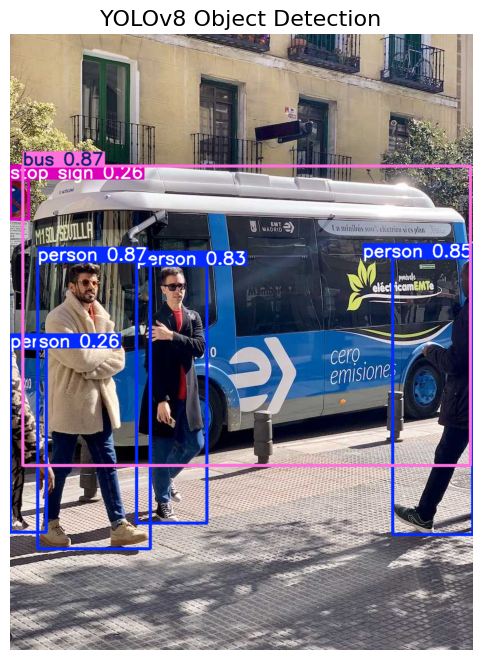

✅ Objects detected: 6


In [9]:
# Phase 3: Run detection on a sample image (local)
import urllib.request

# Use a built-in ultralytics sample image
from ultralytics.utils.downloads import download
from pathlib import Path

# Download via ultralytics (internal method, more reliable)
import ultralytics
assets_path = Path(ultralytics.__file__).parent / "assets"
print(f"Assets found: {list(assets_path.glob('*.jpg'))}")

# Run detection on built-in image
test_img = str(list(assets_path.glob('*.jpg'))[0])
print(f"Using image: {test_img}")

results = model(test_img)

# Show result
img = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("YOLOv8 Object Detection", fontsize=16)
plt.show()

print(f"✅ Objects detected: {len(results[0].boxes)}")

In [10]:
# Phase 4: Detailed results analysis
import pandas as pd

# Extract detection data
boxes = results[0].boxes
names = model.names

data = []
for box in boxes:
    cls_id = int(box.cls[0])
    confidence = float(box.conf[0])
    label = names[cls_id]
    data.append({"Object": label, "Confidence": round(confidence, 3)})

df = pd.DataFrame(data)
df = df.sort_values("Confidence", ascending=False).reset_index(drop=True)

print("=" * 40)
print("   DETECTION RESULTS SUMMARY")
print("=" * 40)
print(df.to_string(index=False))
print("=" * 40)
print(f"Total objects detected: {len(df)}")
print(f"Average confidence:     {df['Confidence'].mean():.3f}")
print(f"Highest confidence:     {df['Confidence'].max():.3f}")

   DETECTION RESULTS SUMMARY
   Object  Confidence
      bus       0.873
   person       0.866
   person       0.853
   person       0.825
   person       0.261
stop sign       0.255
Total objects detected: 6
Average confidence:     0.655
Highest confidence:     0.873


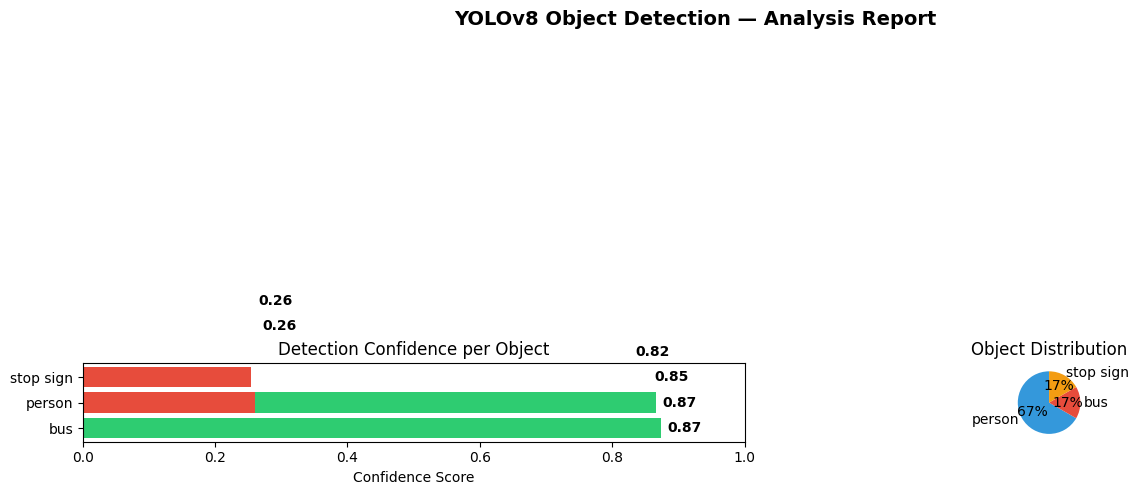

✅ Report saved as detection_report.png


In [11]:
# Phase 5: Professional visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Confidence bar chart
colors = ['#2ecc71' if c > 0.5 else '#e74c3c' for c in df['Confidence']]
axes[0].barh(df['Object'], df['Confidence'], color=colors)
axes[0].set_xlabel('Confidence Score')
axes[0].set_title('Detection Confidence per Object')
axes[0].set_xlim(0, 1)
for i, v in enumerate(df['Confidence']):
    axes[0].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

# Chart 2: Object count pie chart
obj_counts = df['Object'].value_counts()
axes[1].pie(obj_counts.values, labels=obj_counts.index, 
            autopct='%1.0f%%', startangle=90,
            colors=['#3498db','#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('Object Distribution')

plt.suptitle('YOLOv8 Object Detection — Analysis Report', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('detection_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Report saved as detection_report.png")

In [12]:
# Phase 6: Project Summary
print("=" * 50)
print("   YOLOV8 OBJECT DETECTION — PROJECT SUMMARY")
print("=" * 50)
print(f"\n📌 Model      : YOLOv8n (nano)")
print(f"📌 Framework  : Ultralytics + PyTorch")
print(f"📌 Task       : Object Detection")
print(f"\n📊 Results:")
print(f"   • Objects detected : {len(df)}")
print(f"   • Classes found    : {df['Object'].nunique()}")
print(f"   • Avg confidence   : {df['Confidence'].mean():.1%}")
print(f"   • Best detection   : {df.iloc[0]['Object']} ({df.iloc[0]['Confidence']:.1%})")
print(f"\n✅ Output saved : detection_report.png")
print(f"\n🚀 Next steps  :")
print(f"   1. Train on custom dataset (Roboflow)")
print(f"   2. Test on video / webcam")
print(f"   3. Deploy with Streamlit")
print("=" * 50)

   YOLOV8 OBJECT DETECTION — PROJECT SUMMARY

📌 Model      : YOLOv8n (nano)
📌 Framework  : Ultralytics + PyTorch
📌 Task       : Object Detection

📊 Results:
   • Objects detected : 6
   • Classes found    : 3
   • Avg confidence   : 65.5%
   • Best detection   : bus (87.3%)

✅ Output saved : detection_report.png

🚀 Next steps  :
   1. Train on custom dataset (Roboflow)
   2. Test on video / webcam
   3. Deploy with Streamlit


In [ ]:
# Webcam Real-Time Object Detection
import cv2
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

# Open webcam (0 = default camera)
cap = cv2.VideoCapture(0)

print("✅ Webcam started — Press 'Q' to stop")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Cannot access webcam")
        break

    # Run YOLOv8 detection
    results = model(frame, verbose=False)
    annotated = results[0].plot()

    # Show live window
    cv2.imshow("YOLOv8 — Real Time Detection (Press Q to quit)", annotated)

    # Press Q to stop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("✅ Detection stopped")

✅ Webcam started — Press 'Q' to stop
